In [ ]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_probability as tfp
tfd = tfp.distributions

from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [ ]:
dtype = 'float32'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
from uncertainty import *
from utils import *

## Data

In [ ]:
classification = True

In [ ]:
S = 0
sigma = 1
new_sigma = 1

In [ ]:
t1 = 0.3
t2 = 1 - t1

In [ ]:
N = 500 # dataset size
m = 10  # subsample size
n = 500 # training size
J = 50  # number of subsamples

In [ ]:
def compute_rhos(Xs, alpha=-5, beta=10.0):
  return 1/(1 + np.exp(-(alpha + beta*Xs)))

In [ ]:
Xs = np.random.beta(a=0.5, b=0.5, size=N).reshape(-1,1).astype(dtype)
new_Xs = np.random.beta(a=0.5, b=0.5, size=N).reshape(-1,1).astype(dtype)

train_mask = ((Xs < t1) | (Xs > t2))
Xs = Xs[train_mask.flatten()]

d = Xs.shape[1] # data dimension

rhos, new_rhos = compute_rhos(Xs), compute_rhos(new_Xs)

Ys = np.random.binomial(1, rhos).reshape(-1,1).astype(dtype)
new_Ys = np.random.binomial(1, new_rhos).reshape(-1,1).astype(dtype)

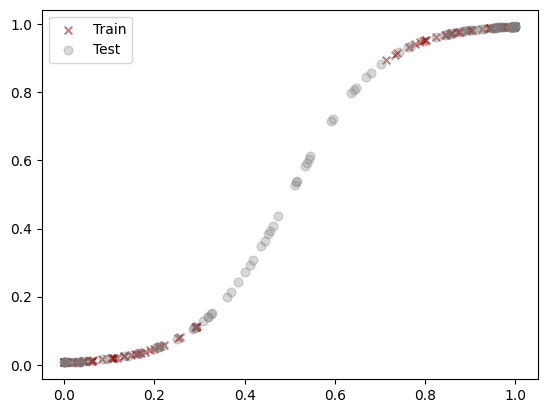

In [ ]:
plot_n = 100
plt.scatter(Xs[0:plot_n], rhos[0:plot_n], alpha=0.5, c='darkred', marker='x',  s=30, label='Train')
plt.scatter(new_Xs[0:plot_n], new_rhos[0:plot_n], color='gray', alpha=0.3, s=40, label='Test')
plt.legend();

#### Embedding $g_\xi$

In [ ]:
representation_dim = 8

In [ ]:
g = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=(d,), name='encoder_imodel_inputnput'),
                               tf.keras.layers.Dense(representation_dim, name='l1')])

#### Prediction model $f_\theta ∘ g_\xi$

In [ ]:
pred_model = tf.keras.Sequential(list(g.layers) + [tf.keras.layers.Dense(1, use_bias=False)])

pred_optimizer = keras.optimizers.Adam(learning_rate=1e-3)
pred_model.compile(optimizer=pred_optimizer, loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])

Train embedding parameters $\xi$ to maximize the likelihood of the training data $(X,Y)$

In [ ]:
# train model on X, Y
%%time
history = pred_model.fit(Xs, Ys, epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4678 - loss: 0.6609   
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4827 - loss: 0.6406 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4866 - loss: 0.6224 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4751 - loss: 0.6022 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4550 - loss: 0.5803 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6652 - loss: 0.5632 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8004 - loss: 0.5513  
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9004 - loss: 0.5374 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9100 - loss: 0.5237 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9413 - loss: 0.5178 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.4936 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/st

In [ ]:
vanilla_predictions = np.array(pred_model(new_Xs)).flatten()

In [ ]:
n_bins = 10

In [ ]:
vanilla_acc, vanilla_ece, vanilla_nll, vanilla_entropy, vanilla_avg_p = binary_metrics(new_Ys, vanilla_predictions, p_true=new_rhos, n_bins=n_bins)
print("accuracy: %.4f, ECE: %.4f, NLL: %.4f, Entropy: %.4f, Average prediction: %.4f" % (vanilla_acc, vanilla_ece, vanilla_nll, vanilla_entropy, vanilla_avg_p))

accuracy: 0.9020, ECE: 2.0789, NLL: 0.9897, Entropy: 0.0365, Average prediction: 0.3722


In [ ]:
# Calculate and sort true train densities
p_Xs = tfp.distributions.Normal(loc=S, scale=sigma)
plot_Xs_pdfs, plot_Xs = get_sorted(p_Xs.prob(Xs), Xs)

# Calculate and sort true test densities
p_new_Xs = tfp.distributions.Normal(loc=S, scale=new_sigma)
plot_new_Xs_pdfs, plot_new_Xs = get_sorted(p_new_Xs.prob(new_Xs), new_Xs)
plot_predictions, _ = get_sorted(vanilla_predictions, new_Xs)
plot_new_Ys, _ = get_sorted(new_Ys, new_Xs)


### VIDS

Define encoder $h_\gamma$

In [ ]:
#############################################
# Encoder
#############################################

In [ ]:
gXstar_inputs = tf.keras.Input(shape=(8,), name="gXstar_input")
gX_summary_input = tf.keras.Input(shape=(8,), name="gX_summary_input")
combined = tf.keras.layers.Concatenate()([gXstar_inputs, gX_summary_input])
gamma_layer = tf.keras.layers.Dense(64 * representation_dim, activation="relu")(combined)
gamma_layer = tf.keras.layers.Dense(32 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(16 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(8 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(4 * representation_dim, activation="relu")(gamma_layer)
gamma = tf.keras.layers.Dense(2 * representation_dim)(gamma_layer)

h = tf.keras.Model(inputs=[gXstar_inputs, gX_summary_input], outputs=gamma)

Train the encoder $h_\gamma$

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
%%time
h, losses = train_posterior(Xs, Ys, g, h, optimizer, J=30, m=20, n=500, K=30, tau=0.001, lambda_val=0.005, classification=True)

  0%|          | 0/30 [00:00<?, ?it/s]

--- iteration 0, loss 1.4706, split var: 0.0424, train loss: 0.6552, test loss: 0.7289, KL: -8.7122 ---
--- iteration 1, loss 1.3495, split var: 0.0509, train loss: 0.4652, test loss: 0.5564, KL: -8.7261 ---
--- iteration 2, loss 1.1003, split var: 0.0186, train loss: 0.4865, test loss: 0.4863, KL: -8.1660 ---
--- iteration 3, loss 0.9849, split var: 0.0288, train loss: 0.4150, test loss: 0.6714, KL: -8.4798 ---
--- iteration 4, loss 0.8480, split var: 0.0231, train loss: 0.4475, test loss: 0.5409, KL: -7.6463 ---
--- iteration 5, loss 0.6905, split var: 0.0160, train loss: 0.3090, test loss: 0.4771, KL: -7.7160 ---
--- iteration 6, loss 0.5253, split var: 0.0132, train loss: 0.2043, test loss: 0.2121, KL: -7.6069 ---
--- iteration 7, loss 0.4344, split var: 0.0157, train loss: 0.1838, test loss: 0.5904, KL: -7.6348 ---
--- iteration 8, loss 0.3606, split var: 0.0119, train loss: 0.1564, test loss: 0.1997, KL: -6.8709 ---
--- iteration 9, loss 0.3106, split var: 0.0134, train loss: 0.1

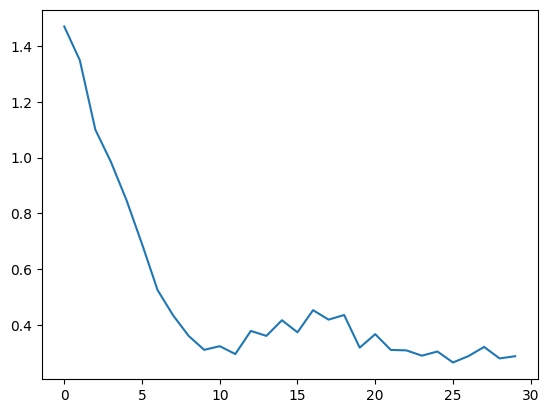

In [ ]:
plt.plot(np.array(losses));

Learned posterior

In [ ]:
use_sampling = True

In [ ]:
# embeddings
gX = g(Xs)
gXstar = g(new_Xs)

posterior_mus, posterior_sigmas =  get_phi(h, gX, gXstar)

# evaluate uncertainty for x*
if use_sampling:
  n_samples_for_avg = 1000
  preds = []
  for i in tqdm(range(n_samples_for_avg)):
    # samples from learned posterior
    epsilon = tf.random.normal(shape=posterior_mus.shape)
    theta_samples =  posterior_mus + epsilon * posterior_sigmas
    # prediction with sampled theta
    fXstar = tf.reduce_sum(theta_samples * gXstar, axis=-1)
    preds.append(tf.nn.sigmoid(fXstar))
  variational_predictions = np.array(preds)
  variational_certainties = np.mean(preds, axis=0)
else:
  variational_predictions = tf.reduce_sum(posterior_mus * gXstar, axis=-1).numpy()
  variational_certainties = variational_predictions

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
posterior_var = np.var(variational_predictions, axis=0)
posterior_std = np.sqrt(posterior_var)

In [ ]:
variational_acc, variational_ece, variational_nll, variational_entropy, variational_avg_p = binary_metrics(new_Ys, variational_certainties, p_true=new_rhos, n_bins=n_bins)
print("accuracy: %.4f, ECE: %.4f, NLL: %.4f, Entropy: %.4f, Average prediction: %.4f" % (variational_acc, variational_ece, variational_nll, variational_entropy, variational_avg_p))

accuracy: 0.9040, ECE: 0.0664, NLL: 0.2504, Entropy: 0.3373, Average prediction: 0.5499
